# Density map
This notebook generates a **2D density map** comparing:

- **Predicted binding score** (model output)
- **CLIP binding score** (experimental signal)

## Library imports

In [1]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

In [2]:
%%R
library(ggplot2)
library(showtext)

## Configuration

```{note}
The notebook registers Calibri via:

- Font name: `calibri`
- Font file path: `/fs1/private/user/wangyubo/.fonts/calibri.ttf`

If your font file lives elsewhere, update the `font_add(...)` path in the notebook.
```

#### Load precomputed results for BRIDGE
```{note}
For convenience, we provide the precomputed results for BRIDGE on Figshare in `cell_type_specific/preds_cache/` folder, which you can download directly.

You can modify `base_dir` below to change where the base_dir is stored.
```

In [3]:
%%R
RBP <- "DDX3X_HepG2"                                # dataset / target name (used for both input .rds and output .pdf)
base_dir <- "/home/wangyubo/code/BRIDGE/results/preds_cache/"  # directory containing your saved .rds objects

font_add("calibri", "/home/wangyubo/.fonts/calibri.ttf")  # register Calibri font from local path
showtext_auto()                                        # enable showtext so ggplot uses the registered fonts
theme_set(theme_bw(base_family = "calibri"))           # set global ggplot theme with Calibri as default base font

bins_n <- 15                                           # number of density contour levels (more bins => finer gradation)
fill_low  <- "#ffffff"                                 # low-density color (white)
fill_high <- "#35478d"                                 # high-density color (deep blue)

pdf_w <- 4.5                                           # output PDF width (inches)
pdf_h <- 4.5                                           # output PDF height (inches)


In [4]:
%%R
rds_path <- file.path(base_dir, paste0(RBP, ".rds"))    # full path to the input .rds file (R object serialized)
obj <- readRDS(rds_path)                                # read the saved R object (expects a list with $data and $meta)
meta <- obj$meta                                        # metadata list: expects n, r, p (sample size, correlation, p-value)
data <- obj$data                                        # main data.frame: columns CLIP_binding_score / Predicted_binding_score
head(data)

  CLIP_binding_score Predicted_binding_score
1           5.339950              -8.4396629
2           5.941947              -1.2290050
3           5.506001              -0.9548271
4           4.640629              -3.4585135
5           2.630361              -2.2650976
6           4.937222               3.9188786


In [5]:
%%R
x_range <- range(data$Predicted_binding_score, na.rm = TRUE)  # x-axis range for placing the text annotation
x_range

[1] -61.37677  30.53658


In [6]:
%%R
y_range <- range(data$CLIP_binding_score, na.rm = TRUE)       # y-axis range for placing the text annotation
y_range

[1] -3.782715  7.189328


## Plots the density map

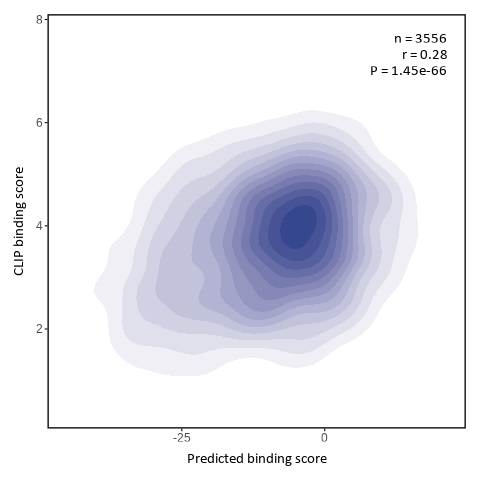

In [7]:
%%R
p <- ggplot(data, aes(y = CLIP_binding_score, x = Predicted_binding_score)) +  # map x/y to your two scores
  stat_density_2d(aes(fill = ..level..), geom = "polygon", color = NA, bins = bins_n) +  # filled 2D density polygons; no border lines
  scale_fill_gradient(low = fill_low, high = fill_high) +  # density color gradient from low -> high
  labs(
    x = "Predicted binding score",                      # x-axis label
    y = "CLIP binding score"                            # y-axis label
  ) +
  annotate(
    "text",
    x = x_range[2] - 0.1 * diff(x_range),               # place near the right edge of x-axis (slightly inset)
    y = y_range[2] + 0.05 * diff(y_range),              # place slightly above the top of y-axis range
    label = sprintf("n = %d\nr = %.2f\nP = %.2e", meta$n, meta$r, meta$p),  # formatted summary stats
    size = 4, hjust = 1, vjust = 1, family = "calibri"  # text size + alignment + font family
  ) +
  theme_bw() +                                          # base theme (white background, black axes)
  theme(
    panel.background = element_blank(),                 # remove any residual panel background fill
    panel.grid.major = element_blank(),                 # remove major gridlines
    panel.grid.minor = element_blank(),                 # remove minor gridlines
    axis.ticks = element_line(colour = "black"),        # draw tick marks in black for clearer axes
    axis.title.x = element_text(margin = margin(t = 10), family = "calibri"),  # add top margin to x title; enforce font
    axis.title.y = element_text(margin = margin(r = 10), family = "calibri"),  # add right margin to y title; enforce font
    plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm"),    # outer margins (top, right, bottom, left) in cm
    legend.position = "none",                           # hide legend (density fill legend not needed)
    panel.border = element_rect(colour = "black", fill = NA, size = 1.25)  # thicker black border around panel
  )

print(p)                                                # render the plot in the current device (e.g., RStudio viewer)


In [8]:
%%R
library(ggplot2)
library(showtext)
library(patchwork)
# -----------------------------
# Inputs
# -----------------------------
RBPs <- c("NCBP2_HepG2", "TIA1_HepG2")

# Use the correct preds_cache directory in your project
base_dir <- "/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/results/preds_cache"

# Font (optional). If you don't have Calibri, comment these two lines out.
font_add("calibri", "/home/wangyubo/.fonts/calibri.ttf")
showtext_auto()
theme_set(theme_bw(base_family = "calibri"))

# Plot parameters
bins_n    <- 15
fill_low  <- "#ffffff"
fill_high <- "#35478d"

# -----------------------------
# Plot function
# -----------------------------
plot_density_one <- function(RBP, base_dir, bins_n, fill_low, fill_high) {

  rds_path <- file.path(base_dir, paste0(RBP, ".rds"))
  if (!file.exists(rds_path)) {
    message("[Skip] Missing: ", rds_path)
    return(invisible(NULL))
  }

  obj  <- readRDS(rds_path)
  meta <- obj$meta
  data <- obj$data

  # Expect columns: CLIP_binding_score / Predicted_binding_score
  x_range <- range(data$Predicted_binding_score, na.rm = TRUE)
  y_range <- range(data$CLIP_binding_score,     na.rm = TRUE)

  p <- ggplot(data, aes(x = Predicted_binding_score, y = CLIP_binding_score)) +
    # NOTE: use color = NA (no border). after_stat(level) works in newer ggplot2
    stat_density_2d(aes(fill = after_stat(level)),
                    geom = "polygon", color = NA, bins = bins_n) +
    scale_fill_gradient(low = fill_low, high = fill_high) +
    labs(
      x = "Predicted binding score",
      y = "CLIP binding score",
      title = RBP
    ) +
    annotate(
      "text",
      x = x_range[2] - 0.1 * diff(x_range),
      y = y_range[2] + 0.05 * diff(y_range),
      label = sprintf("n = %d\nr = %.2f\nP = %.2e", meta$n, meta$r, meta$p),
      size = 4, hjust = 1, vjust = 1, family = "calibri"
    ) +
    theme_bw() +
    theme(
      panel.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      axis.ticks = element_line(colour = "black"),
      axis.title.x = element_text(margin = margin(t = 10), family = "calibri"),
      axis.title.y = element_text(margin = margin(r = 10), family = "calibri"),
      plot.margin  = unit(c(0.5, 0.5, 0.5, 0.5), "cm"),
      legend.position = "none",
      panel.border = element_rect(colour = "black", fill = NA, size = 1.25)
    )

  return(p)
}

# -----------------------------
# Loop over RBPs (show plots)
# -----------------------------
plots <- lapply(RBPs, function(rbp) plot_density_one(rbp, base_dir, bins_n, fill_low, fill_high))
plots <- Filter(Negate(is.null), plots)


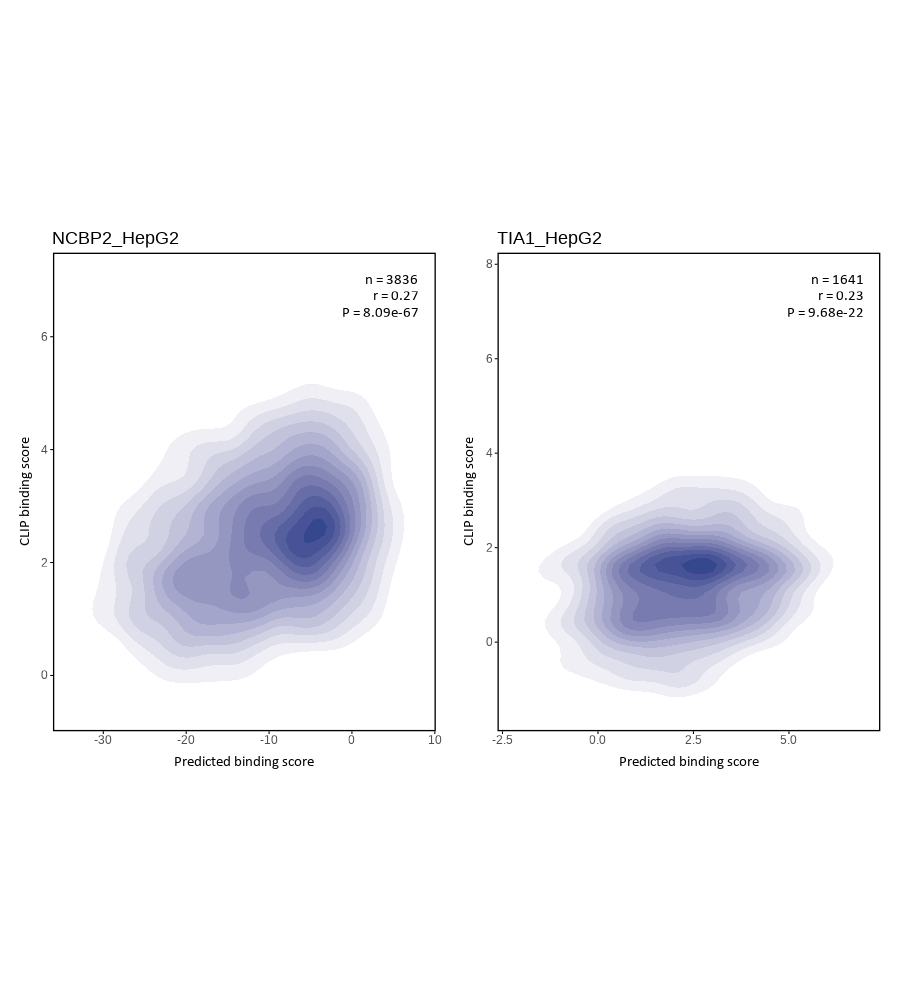

In [9]:
%%R -w 900 -h 1000
wrap_plots(plots, ncol = 2) & theme(aspect.ratio = 1.25)